# Explainable AI — XGBoost

This notebook explains the validation-selected XGBoost model with SHAP. `V1`–`V28` remain anonymized PCA components; no semantic meaning is invented for them.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import load_dataset, split_dataset
from src.explainability import build_shap_explainer, compute_shap_values
from src.models import build_xgboost
from src.preprocessing import build_tree_preprocessor, fit_transform_splits

random_state = 42
rng = np.random.default_rng(random_state)


In [2]:
transaction_dataset = load_dataset(project_root / "data" / "creditcard.csv")
(
    training_features,
    validation_features,
    test_features,
    training_labels,
    validation_labels,
    test_labels,
) = split_dataset(transaction_dataset, random_state=random_state)

tree_preprocessor = build_tree_preprocessor(training_features.columns.tolist())
tree_training_features, tree_validation_features, _, _ = fit_transform_splits(
    tree_preprocessor,
    training_features,
    validation_features,
    test_features,
)

fraud_count = int(training_labels.sum())
legitimate_count = len(training_labels) - fraud_count

xgboost_model = build_xgboost(random_state=random_state)
xgboost_model.set_params(scale_pos_weight=legitimate_count / fraud_count)
xgboost_model.fit(tree_training_features, training_labels)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [3]:
background_size = min(1000, len(tree_training_features))
explanation_size = min(500, len(tree_validation_features))

background_indices = rng.choice(len(tree_training_features), size=background_size, replace=False)
explanation_indices = rng.choice(len(tree_validation_features), size=explanation_size, replace=False)

background_features = tree_training_features[background_indices]
explained_features = tree_validation_features[explanation_indices]

explainer = build_shap_explainer(xgboost_model, background_features)
shap_values = compute_shap_values(explainer, explained_features)

print("SHAP matrix:", shap_values.shape)


SHAP matrix: (500, 30)


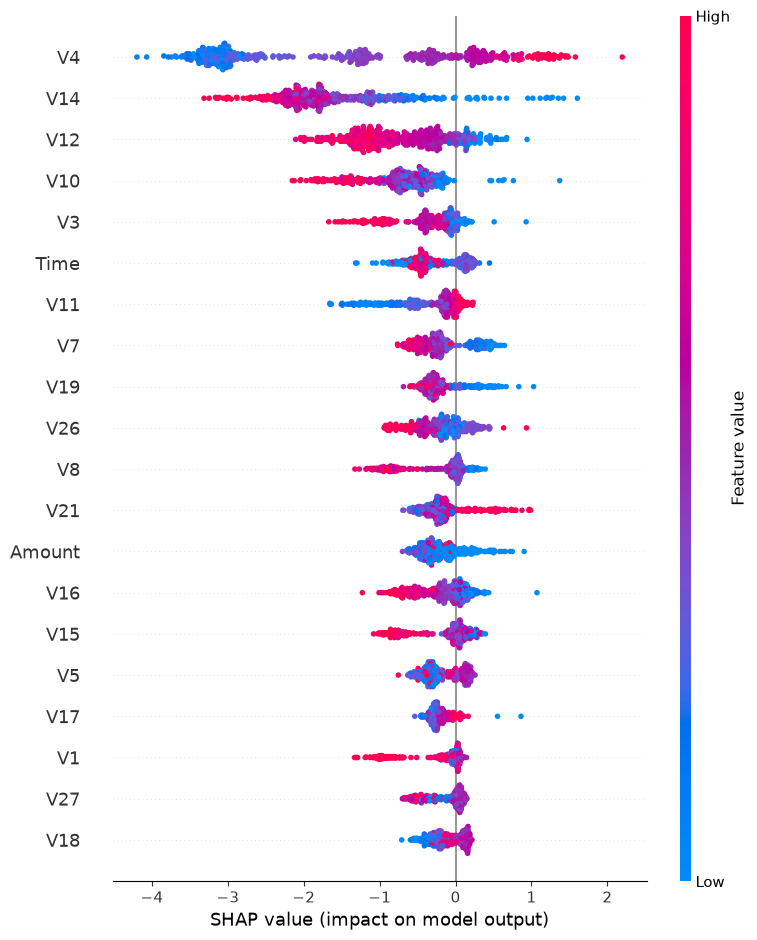

In [4]:
figure_directory = project_root / "outputs" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

feature_names = training_features.columns.tolist()

shap.summary_plot(
    shap_values,
    explained_features,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.savefig(figure_directory / "xgboost_shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()


In [5]:
mean_absolute_shap = np.abs(shap_values).mean(axis=0)
importance_table = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_absolute_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

importance_table.head(10)


,feature,mean_abs_shap
0,V4,1.733763
1,V14,1.660293
2,V12,0.757562
3,V10,0.739135
4,V3,0.362137
5,Time,0.356775
6,V11,0.339674
7,V7,0.339526
8,V19,0.296298
9,V26,0.295206


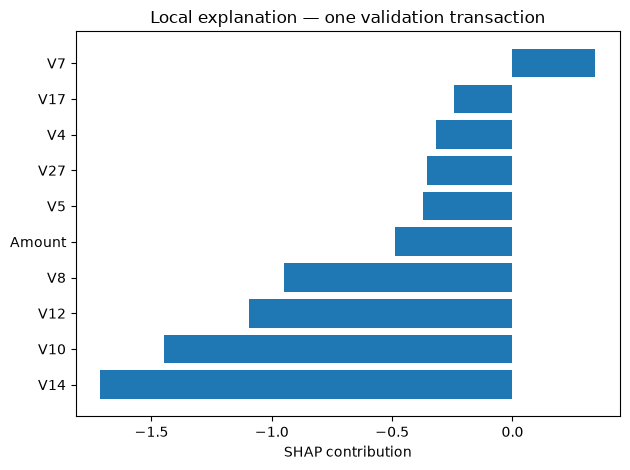

In [6]:
local_index = 0
local_contributions = (
    pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values[local_index],
    })
    .assign(abs_shap=lambda table: table["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
    .head(10)
    .sort_values("shap_value")
)

plt.figure()
plt.barh(local_contributions["feature"], local_contributions["shap_value"])
plt.xlabel("SHAP contribution")
plt.title("Local explanation — one validation transaction")
plt.tight_layout()
plt.savefig(figure_directory / "xgboost_shap_local_example.png", dpi=160, bbox_inches="tight")
plt.show()


## Interpretation

SHAP identifies which anonymized components contribute most to the model output, globally and for an individual validation transaction. Because `V1`–`V28` are PCA-anonymized, the analysis reports their influence without assigning real-world meanings to those components.
